# Imports

In [1]:
import gymnasium as gym
import torch
from torch import nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation, rc
from IPython.display import HTML
from pylab import rcParams
from tqdm import tqdm
import os

rcParams['figure.figsize'] = 5, 3  # 设置matplotlib图形的默认大小

# Environment

In [2]:
def make_env():
    """创建一个BipedalWalker-v3环境，并应用观察和奖励缩放包装器。"""
    env = gym.make('BipedalWalker-v3', render_mode="rgb_array")
    return RewardScalingWrapper(ObservationScalingWrapper(env))

In [3]:
class ObservationScalingWrapper(gym.ObservationWrapper):
    """将观察值缩放到-1到+1的范围内。"""
    def __init__(self, env):
        super().__init__(env)

    def observation(self, observation):
        """缩放观察值。"""
        observation[0] *= 1. / 3.14
        observation[1] *= 0.2
        observation[2] *= 0.2
        observation[3] *= 0.2
        observation[4] *= 1. / 3.14
        observation[5] *= 0.2
        observation[6] *= 1.0 / 3.14
        observation[7] *= 0.2
        observation[8] *= 0.2
        observation[9] *= 1. / 3.14
        observation[10] *= 0.2
        observation[11] *= 1. / 3.14
        observation[12] *= 0.2
        observation[13] *= 0.2
        return observation

In [4]:
class RewardScalingWrapper(gym.RewardWrapper):
    """按给定的因子缩放奖励。"""
    def __init__(self, env, scaling_factor=1./5):
        super().__init__(env)
        self.scaling_factor = scaling_factor  # 设置缩放因子

    def reward(self, reward):
        """缩放奖励。"""
        return reward * self.scaling_factor  # 返回缩放后的奖励

# Replay Buffer

In [5]:
class ReplayBuffer:
    def __init__(self, max_size: int, observation_space: gym.spaces.Space, action_space: gym.spaces.Space, seed: int | None = None, device="cpu"):
        """存储回放历史，最多存储`max_size`个条目，并根据需要删除旧条目。"""
        self.max_size = max_size  # 设置最大缓冲区大小
        self.observation_space = observation_space  # 设置观察空间
        self.action_space = action_space  # 设置动作空间
        self.ptr = 0  # 设置缓冲区指针，指向下一个要添加的条目
        self.size = 0  # 设置缓冲区当前大小
        self.device = device  # 设置存储设备

        # 初始化存储观察、动作、奖励、下一个观察和完成标志的张量
        self.observations = torch.zeros((max_size, *observation_space.shape), dtype=torch.float32, device=self.device)
        self.actions = torch.zeros((max_size, action_space.shape[0]), dtype=torch.float32, device=self.device)
        self.rewards = torch.zeros(max_size, dtype=torch.float32, device=self.device)
        self.next_observations = torch.zeros((max_size, *observation_space.shape), dtype=torch.float32, device=self.device)
        self.dones = torch.zeros(max_size, dtype=torch.bool, device=self.device)

        if seed is not None:
            np.random.seed(seed)  # 如果提供了种子，则设置NumPy的随机种子

    def add(self, current_observations: np.ndarray, actions: np.ndarray, rewards: np.ndarray, next_observations: np.ndarray, dones: np.ndarray) -> None:
       """向缓冲区添加新条目。

        参数:
            current_observations: 当前步骤观察到的环境状态
            actions: 模型采取的动作
            rewards: 采取动作后收到的奖励
            next_observations: 采取动作后观察到的环境状态
            dones: 是否结束了 episode
        """
        # 将NumPy数组转换为PyTorch张量并存储到缓冲区中
        self.observations[self.ptr] = torch.tensor(current_observations, dtype=torch.float32, device=self.device)
        self.actions[self.ptr] = torch.tensor(actions, dtype=torch.float32, device=self.device)
        self.rewards[self.ptr] = torch.tensor(rewards, dtype=torch.float32, device=self.device)
        self.next_observations[self.ptr] = torch.tensor(next_observations, dtype=torch.float32, device=self.device)
        self.dones[self.ptr] = torch.tensor(dones, dtype=torch.bool, device=self.device)

        self.ptr = (self.ptr + 1) % self.max_size  # 更新指针，循环使用缓冲区
        self.size = min(self.size + 1, self.max_size)  # 更新缓冲区大小，不超过最大值

    def sample(self, n_samples: int, replace: bool = True) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
        """从缓冲区随机采样`n_samples`个条目。

        参数:
            n_samples: 要选择的样本数
            replace: 是否有放回地采样

        返回:
            当前观察、动作、奖励、下一个观察、完成标志
        """
        indices = np.random.choice(self.size, size=n_samples, replace=replace)  # 随机选择索引
        # 返回采样得到的张量
        return self.observations[indices], self.actions[indices], self.rewards[indices], self.next_observations[indices], self.dones[indices]

    def clear(self) -> None:
        """清空缓冲区"""
        self.ptr = 0
        self.size = 0

    def __getitem__(self, index: int | np.ndarray) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
        """获取`index`处的样本。

        参数:
            index: 要获取的样本的索引

        返回:
            当前观察、动作、奖励、下一个观察、完成标志
        """
        # 返回指定索引处的张量
        return self.observations[index], self.actions[index], self.rewards[index], self.next_observations[index], self.dones[index]

    def __len__(self) -> int:
        """返回缓冲区中的条目数"""
        return self.size

# Model

In [6]:
class Actor(nn.Module):
    def __init__(self, state_shape, action_dim):
        super().__init__()
        hidden_size = 256  # 设置隐藏层大小
        # 定义神经网络层
        self.dense_1 = nn.Linear(state_shape, hidden_size)
        self.dense_2 = nn.Linear(hidden_size, hidden_size)
        self.dense_3 = nn.Linear(hidden_size, action_dim)
        self.action_dim = action_dim  # 设置动作维度

    def forward(self, x):
        x = F.relu(self.dense_1(x))
        x = F.relu(self.dense_2(x))  # 激活函数ReLU
        x = torch.tanh(self.dense_3(x))  # 输出层激活函数tanh
        return x

class Critic(nn.Module):
    def __init__(self, state_shape, action_dim):
        super().__init__()
        hidden_size = 256  # 设置隐藏层大小
        # Q1 架构
        self.dense_1 = nn.Linear(state_shape + action_dim, hidden_size)
        self.dense_2 = nn.Linear(hidden_size, hidden_size)
        self.dense_3 = nn.Linear(hidden_size, 1)
        # Q2 架构
        self.dense_4 = nn.Linear(state_shape + action_dim, hidden_size)
        self.dense_5 = nn.Linear(hidden_size, hidden_size)
        self.dense_6 = nn.Linear(hidden_size, 1)

    def forward(self, x, x_actions):
        x = torch.cat([x, x_actions], dim=1)  # 将状态和动作连接起来
        q1 = F.relu(self.dense_1(x))
        q1 = F.relu(self.dense_2(q1))  # Q1激活函数ReLU
        q1 = self.dense_3(q1)  # Q1输出
        q2 = F.relu(self.dense_4(x))
        q2 = F.relu(self.dense_5(q2))  # Q2激活函数ReLU
        q2 = self.dense_6(q2)  # Q2输出
        return q1, q2

    def forward_q1(self, x, x_actions):
        """前向传播，只返回Q1的值"""
        x = torch.cat([x, x_actions], dim=1)  # 将状态和动作连接起来
        x = F.relu(self.dense_1(x))
        x = F.relu(self.dense_2(x))  # Q1激活函数ReLU
        x = self.dense_3(x)  # Q1输出
        return x

    # 双 Q 网络（Twin Q-Networks）TD3
    # 通过使用两个独立的 Q 网络，并选择较小的 Q 值作为目标 Q 值，从而减少 Q 值高估的影响。
    # 有助于提高 Q 值估计的准确性，并改善强化学习算法的性能。

# Play the game

In [7]:
class GaussianNoiseGenerator:
    def __init__(self, sigma=0.1, seed=None):
        """初始化高斯噪声生成器。通过添加高斯噪声，让动作有一定随机性，尝试更多可能性
        TD3 算法的关键改进之一是目标策略平滑（Target Policy Smoothing），即在计算目标 Q 值时，对目标动作添加噪声

        参数:
            sigma: 噪声的标准差
            seed: 随机种子，用于可重复性
        """
        self.sigma = sigma
        self.rng = np.random.RandomState(seed)  # 初始化随机数生成器

    def sample(self, *args):
        return self.sigma * self.rng.randn(*args)  # 生成指定形状的高斯噪声

In [8]:
def play_game(
    model: nn.Module,
    buffer: ReplayBuffer,
    env: gym.Env,
    steps: int,
    gaussian_noise,
    observations: np.ndarray | None = None,
    one_episode: bool = False,
    device="cpu"
) -> np.ndarray:
    """使用模型`model`在环境`env`中进行游戏，总共`steps`步。

    参数:
        model: 要使用的模型
        buffer: 存储结果的缓冲区
        env: 要使用的环境
        steps: 要记录的总步数
        gaussian_noise: 噪声生成器
        observations: 起始观察
        one_episode: 如果一个环境结束，则退出
        device: 运行模型的设备

    返回:
        最后的观察
    """
    if observations is None:
        observations, _ = env.reset()  # 如果没有提供起始观察，则重置环境

    total_steps = 0  # 初始化总步数
    progress_bar = tqdm(total=steps, desc="Playing Game")  # 初始化进度条

    while total_steps < steps:
        # 使用模型生成动作，并添加高斯噪声
        actions = model(torch.tensor(observations, dtype=torch.float32, device=device).unsqueeze(0)).cpu().numpy()
        noise = gaussian_noise.sample(env.action_space.shape[0])
        actions = np.clip(actions + noise, a_min=-1, a_max=1)  # 裁剪动作到[-1, 1]范围
        # 执行动作并获取下一个观察、奖励、是否结束
        next_observations, rewards, terminated, truncated, _ = env.step(actions[0])
        done = terminated or truncated

        # 将经验添加到缓冲区
        buffer.add(observations, actions[0], rewards, next_observations, done)

        observations = next_observations  # 更新观察
        total_steps += 1  # 更新总步数
        progress_bar.update(1)  # 更新进度条

        if done and one_episode:
            break  # 如果结束并且只玩一个episode，则退出
        if done:
            observations, _ = env.reset()  # 如果结束，则重置环境

    progress_bar.close()  # 关闭进度条
    return observations  # 返回最后的观察

# Loss

In [9]:
def ddpg_loss(
    current_observation: torch.Tensor,
    action: torch.Tensor,
    reward: torch.Tensor,
    next_observation: torch.Tensor,
    done: torch.Tensor,
    q_model: nn.Module,
    policy_model: nn.Module,
    target_q_model: nn.Module,
    target_policy_model: nn.Module,
    gamma: float,
    gaussian_noise,
    clip_noise,
    action_low,
    action_high
) -> tuple[torch.Tensor, torch.Tensor]:
    """计算深度确定性策略梯度 (DDPG) 损失。

    参数:
        current_observation: 当前时间步的观察
        action: 当前时间步采取的动作
        reward: 当前时间步的奖励
        next_observation: 下一个时间步的观察
        done: episode 是否结束
        q_model: Q函数模型
        policy_model: 动作预测模型
        target_q_model: 目标 Q 函数模型
        target_policy_model: 目标动作预测模型
        gamma: 折扣因子
        gaussian_noise: 目标策略平滑的噪声生成器
        clip_noise: 噪声的裁剪值
        action_low: 动作裁剪的下界
        action_high: 动作裁剪的上界

    返回:
        Q函数和策略模型的计算损失
    """
    with torch.no_grad():
        # 计算目标 Q 值
        # 生成噪声并裁剪
        noise = torch.tensor(gaussian_noise.sample(action.shape[0], policy_model.action_dim), dtype=torch.float32, device=current_observation.device).clamp(-clip_noise, clip_noise)
        # 使用目标策略模型生成动作，并添加噪声和裁剪
        next_action = torch.clamp(target_policy_model(next_observation).detach() + noise, min=action_low, max=action_high)
        # 使用目标 Q 函数模型计算 Q 值
        target_Q1, target_Q2 = target_q_model(next_observation, next_action)
        # 选择最小的 Q 值
        target_Q = torch.min(target_Q1, target_Q2)
        # 计算目标 Q 值
        target_Q = reward.squeeze() + gamma * (1 - done.int()) * target_Q.squeeze()  # 贝尔曼方程

    # 使用 Q 函数模型计算当前 Q 值
    current_Q1, current_Q2 = q_model(current_observation, action)
    # 计算 MSE 损失，即预测 Q 值与目标 Q 值之间的差异
    q_loss = F.mse_loss(current_Q1.squeeze(), target_Q) + F.mse_loss(current_Q2.squeeze(), target_Q)
    # 计算策略损失，即 Actor 网络的损失，通过最大化 Q 函数，优化 Actor 网络的策略
    policy_loss = -q_model.forward_q1(current_observation, policy_model(current_observation)).mean()

    return q_loss, policy_loss  # 返回 Q 函数和策略损失

# Training

In [10]:
def save_checkpoint(checkpoint_path, actor_model, critic_model, actor_optimizer, critic_optimizer, total_steps, logger_episode_rewards, logger_episode_lengths):
    checkpoint = {
        'actor_state_dict': actor_model.state_dict(),  # 保存 Actor 模型的状态字典
        'critic_state_dict': critic_model.state_dict(),  # 保存 Critic 模型的状态字典
        'actor_optimizer_state_dict': actor_optimizer.state_dict(),  # 保存 Actor 优化器的状态字典
        'critic_optimizer_state_dict': critic_optimizer.state_dict(),  # 保存 Critic 优化器的状态字典
        'total_steps': total_steps,  # 保存当前总步数
        'episode_rewards': logger_episode_rewards,  # 保存每 episode 奖励记录
        'episode_lengths': logger_episode_lengths  # 保存每 episode 长度记录
    }
    torch.save(checkpoint, checkpoint_path)  # 保存检查点
    print(f"Checkpoint saved to {checkpoint_path}")

In [11]:
def train(env, config, actor_model, critic_model, actor_target, critic_target, buffer, actor_optimizer, critic_optimizer, gaussian_noise, device):
    """实现训练循环，显示训练进度并执行模型评估。

    参数:
        env: Gym 环境
        config: 配置字典
        actor_model: Actor 模型
        critic_model: Critic 模型
        actor_target: 目标 Actor 模型
        critic_target: 目标 Critic 模型
        buffer: 回放缓冲区
        actor_optimizer: Actor 优化器
        critic_optimizer: Critic 优化器
        gaussian_noise: 高斯噪声生成器
        device: 运行训练的设备
    """
    max_timesteps = config['max_timesteps']  # 最大时间步数
    start_timesteps = config['start_timesteps']  # 开始训练前随机探索的步数
    batch_size = config['batch_size']  # 批次大小
    gamma = config['gamma']  # 折扣因子
    policy_freq = config['policy_freq']  # 策略更新频率
    tau = config['tau']  # 目标网络软更新参数
    clip_noise = config['clip_noise']  # 噪声裁剪值
    action_low = config['action_low']  # 动作下界
    action_high = config['action_high']  # 动作上界
    updates_per_step = config['updates_per_step']  # 每个时间步的更新次数


    logger_episode_rewards = []  # 记录每 episode 奖励
    logger_episode_lengths = []  # 记录每 episode 长度
    episode_rewards_ma = 0  # 移动平均奖励
    episode_lengths_ma = 0  # 移动平均长度

    state, _ = env.reset()  # 重置环境
    cumulative_reward = 0  # 累积奖励
    current_episode_length = 0  # 当前 episode 长度
    total_steps = 0  # 总步数
    new_line_every = 25000  # 每 25000 步换行

    progress_bar_train = tqdm(total=max_timesteps, desc="Training")  # 初始化训练进度条
    checkpoint_interval = 500000  # 每 500000 步保存一次 checkpoint
    for current_timestep in range(max_timesteps):
        if len(buffer) < start_timesteps:
            action = env.action_space.sample()  # 随机探索
        else:
            actor_model.eval()  # Actor 模型设置为评估模式
            with torch.no_grad():
                # 使用 Actor 模型生成动作
                action = actor_model(torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)).cpu().numpy()[0]
            actor_model.train()  # Actor 模型设置回训练模式

            noise = gaussian_noise.sample(env.action_space.shape[0])  # 生成噪声
            action = np.clip(action + noise, a_min=action_low, a_max=action_high)  # 添加噪声并裁剪动作

        next_state, reward, terminated, truncated, _ = env.step(action)  # 执行动作
        done = terminated or truncated  # 判断 episode 是否结束

        buffer.add(state, action, reward, next_state, done)  # 添加经验到回放缓冲区

        cumulative_reward += reward  # 更新累积奖励
        current_episode_length += 1  # 更新 episode 长度

        if done:
            logger_episode_rewards.append(cumulative_reward)  # 记录 episode 奖励
            logger_episode_lengths.append(current_episode_length)  # 记录 episode 长度
            episode_rewards_ma = np.mean(logger_episode_rewards[-50:])  # 计算移动平均奖励
            episode_lengths_ma = np.mean(logger_episode_lengths[-50:])  # 计算移动平均长度
            cumulative_reward = 0  # 重置累积奖励
            current_episode_length = 0  # 重置 episode 长度
            state, _ = env.reset()  # 重置环境
        else:
            state = next_state  # 更新状态

        total_steps += 1  # 更新总步数
        progress_bar_train.update(1)  # 更新进度条

        if current_timestep < start_timesteps:  # 如果未达到开始训练的步数，则继续
            continue

        for _ in range(updates_per_step):
            states, actions, rewards, next_states, dones = buffer.sample(batch_size)  # 从回放缓冲区采样

            critic_optimizer.zero_grad()  # 清空 Critic 优化器梯度
            # 计算 DDPG 损失
            q_loss, policy_loss = ddpg_loss(states, actions, rewards, next_states, dones,
                                            critic_model, actor_model, critic_target, actor_target,
                                            gamma, gaussian_noise, clip_noise, action_low, action_high)
            q_loss.backward()  # 反向传播 Q 函数损失
            critic_optimizer.step()  # 更新 Critic 模型参数

            if current_timestep % policy_freq == 0:
                # 冻结 critic 参数，防止梯度反传到 critic
                for param in critic_model.parameters():
                    param.requires_grad = False

                actor_optimizer.zero_grad()  # 清空 Actor 优化器梯度
                # 重新计算 actor 损失，注意：此处不使用 ddpg_loss 返回的 policy_loss  避免 Critic 梯度干扰 Actor 更新
                policy_loss = -critic_model.forward_q1(states, actor_model(states)).mean()  # 计算 Actor 损失
                policy_loss.backward()  # 反向传播 Actor 损失
                actor_optimizer.step()  # 更新 Actor 模型参数

                # 恢复 critic 参数梯度计算
                for param in critic_model.parameters():
                    param.requires_grad = True

                # 软更新  是指每次更新时，只对目标网络的参数进行少量更新，使其逐渐接近 Actor 网络和 Critic 网络的参数
                for param, target_param in zip(critic_model.parameters(), critic_target.parameters()):
                    target_param.data = tau * param.data + (1 - tau) * target_param.data

                for param, target_param in zip(actor_model.parameters(), actor_target.parameters()):
                    target_param.data = tau * param.data + (1 - tau) * target_param.data

        end_char = "\n" if total_steps % new_line_every == 0 else "\r"  # 判断是否换行
        if total_steps % 2000 == 0:
            print(f"Step: {total_steps}/{max_timesteps} | Avg reward: {episode_rewards_ma:.4f} | Avg length: {episode_lengths_ma:.2f}", end=end_char)
        
        # 定期保存 checkpoint
        if total_steps % checkpoint_interval == 0:
            save_checkpoint(config['checkpoint_path'], actor_model, critic_model, actor_optimizer, critic_optimizer, total_steps, logger_episode_rewards, logger_episode_lengths)


    progress_bar_train.close()  # 关闭进度条
    save_checkpoint(config['checkpoint_path'], actor_model, critic_model, actor_optimizer, critic_optimizer, total_steps, logger_episode_rewards, logger_episode_lengths) # 训练结束时再保存一次
    return logger_episode_rewards

In [12]:
config = {
    'learning_rate_actor': 0.0001,  # Actor 网络的学习率
    'learning_rate_critic': 0.0001,  # Critic 网络的学习率
    'tau': 0.005,  # 目标网络软更新参数
    'buffer_max_length': 500000,  # 回放缓冲区最大长度
    'batch_size': 128,  # 批次大小
    'start_timesteps': 10000,  # 开始训练前随机探索的步数
    'updates_per_step': 1,  # 每个时间步的更新次数
    'policy_freq': 2,  # 策略更新频率（每两次 Critic 网络（Q 函数网络）更新后，才更新一次 Actor 网络）
    'gamma': 0.99,  # 折扣因子
    'sigma': 0.2,  # 高斯噪声标准差
    'clip_noise': 0.5,  # 噪声裁剪值
    'action_low': -1,  # 动作下界  因为输出层使用了tanh函数，tanh的输出范围就是 -1 到 1
    'action_high': 1,  # 动作上界
    'max_timesteps': 500000,  # 最大时间步数
    'model_save_path': r'C:\Users\lcf14\Desktop\RL\Walker',  # 模型保存路径
    'checkpoint_path': r'C:\Users\lcf14\Desktop\RL\Walker\checkpoint.pth'  # checkpoint 保存路径
}

In [13]:
# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Environment
env = make_env()
state_shape = env.observation_space.shape[0]  # 获取状态空间维度
action_dim = env.action_space.shape[0]  # 获取动作空间维度

# Replay buffer
buffer = ReplayBuffer(config['buffer_max_length'], env.observation_space, env.action_space, device=device)  # 创建回放缓冲区

# Models
actor_model = Actor(state_shape, action_dim).to(device)  # 创建 Actor 模型并移动到设备
critic_model = Critic(state_shape, action_dim).to(device)  # 创建 Critic 模型并移动到设备
actor_target = Actor(state_shape, action_dim).to(device)  # 创建目标 Actor 模型并移动到设备
critic_target = Critic(state_shape, action_dim).to(device)  # 创建目标 Critic 模型并移动到设备

# Initialize target networks
actor_target.load_state_dict(actor_model.state_dict())  # 初始化目标 Actor 网络参数
critic_target.load_state_dict(critic_model.state_dict())  # 初始化目标 Critic 网络参数

# Optimizers
actor_optimizer = torch.optim.Adam(actor_model.parameters(), lr=config['learning_rate_actor'])  # 创建 Actor 优化器
critic_optimizer = torch.optim.Adam(critic_model.parameters(), lr=config['learning_rate_critic'])  # 创建 Critic 优化器

# 加载 checkpoint (如果在 checkpoint_path 存在)
start_step = 0
if os.path.exists(config['checkpoint_path']):
    checkpoint = torch.load(config['checkpoint_path'])  # 加载 checkpoint
    actor_model.load_state_dict(checkpoint['actor_state_dict'])  # 加载 Actor 模型状态字典
    critic_model.load_state_dict(checkpoint['critic_state_dict'])  # 加载 Critic 模型状态字典
    actor_optimizer.load_state_dict(checkpoint['actor_optimizer_state_dict'])  # 加载 Actor 优化器状态字典
    critic_optimizer.load_state_dict(checkpoint['critic_optimizer_state_dict'])  # 加载 Critic 优化器状态字典
    start_step = checkpoint['total_steps']  # 获取 checkpoint 中的总步数
    episode_rewards = checkpoint['episode_rewards']  # 加载之前的 episode_rewards
    episode_lengths = checkpoint['episode_lengths']  # 加载之前的 episode_lengths
    print(f"Checkpoint loaded from {config['checkpoint_path']}, 续训步数从 {start_step} 开始。")
else:
    # 初始化 target networks (仅在没有 checkpoint 时进行初始化，否则加载 checkpoint 会覆盖)
    actor_target.load_state_dict(actor_model.state_dict())  # 初始化目标 Actor 网络参数
    critic_target.load_state_dict(critic_model.state_dict())  # 初始化目标 Critic 网络参数
    episode_rewards = []  # 初始化 episode_rewards
    episode_lengths = []  # 初始化 episode_lengths

# Gaussian Noise Generator
gaussian_noise = GaussianNoiseGenerator(config['sigma'])  # 创建高斯噪声生成器

Using device: cuda


In [14]:
torch.autograd.set_detect_anomaly(True)  # 开启异常检测
# Training
episode_rewards = train(
    env, config, actor_model, critic_model, actor_target, critic_target, buffer, actor_optimizer, critic_optimizer, gaussian_noise, device
)

Training:   2%|█▍                                                            | 12002/500000 [03:10<12:13:49, 11.08it/s]

Step: 12000/500000 | Avg reward: -22.2151 | Avg length: 362.94

Training:   3%|█▋                                                            | 14002/500000 [06:11<11:47:11, 11.45it/s]

Step: 14000/500000 | Avg reward: -22.5694 | Avg length: 356.59

Training:   3%|█▉                                                            | 16003/500000 [09:16<11:59:08, 11.22it/s]

...

Step: 496000/500000 | Avg reward: 46.4543 | Avg length: 1320.34

Training: 100%|████████████████████████████████████████████████████████████▊| 498002/500000 [12:36:27<02:49, 11.77it/s]

Step: 498000/500000 | Avg reward: 46.4712 | Avg length: 1323.82

Training: 100%|█████████████████████████████████████████████████████████████| 500000/500000 [12:39:31<00:00, 10.97it/s]

Step: 500000/500000 | Avg reward: 47.6811 | Avg length: 1331.98
Checkpoint saved to C:\Users\lcf14\Desktop\RL\Walker\checkpoint.pth
Checkpoint saved to C:\Users\lcf14\Desktop\RL\Walker\checkpoint.pth


In [15]:
# 保存模型
if not os.path.exists(config['model_save_path']):
    os.makedirs(config['model_save_path'])
torch.save(actor_model.state_dict(), os.path.join(config['model_save_path'], 'actor_model.pth'))
torch.save(critic_model.state_dict(), os.path.join(config['model_save_path'], 'critic_model.pth'))
print(f"模型已保存到: {config['model_save_path']}")

模型已保存到: C:\Users\lcf14\Desktop\RL\Walker


# Testing

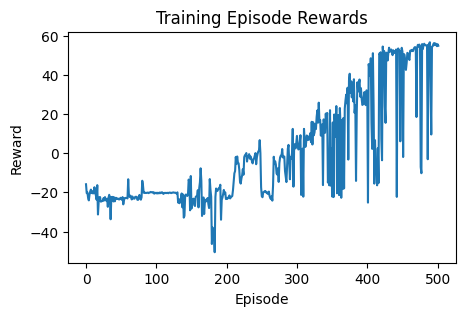

In [16]:
# 绘制训练过程奖励变化
plt.figure()
plt.plot(episode_rewards)
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.title('Training Episode Rewards')
plt.show()

In [17]:
def play_n_render_frames(env, num_frame=50, agent=None, device="cpu"):
    """播放环境并渲染帧。"""
    state, _ = env.reset()  # 重置环境，获取初始状态
    score = 0  # 初始化得分
    frames = []  # 初始化帧列表
    for _ in range(num_frame):
        state_tensor = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)  # 将状态转换为张量，并添加到批次维度
        if agent is None:
            action = env.action_space.sample()  # 如果没有提供 agent，则随机采样动作
        else:
            agent.eval()   # 将 agent 设置为评估模式
            with torch.no_grad():
                action = agent(state_tensor).cpu().numpy()[0]  # 使用 agent 生成动作
            agent.train()  # 将 agent 设置回训练模式
        state, reward, done, trunc, _ = env.step(action)  # 执行动作，获取下一个状态、奖励、是否结束等信息
        score += reward  # 更新得分
        if done or trunc:
            print(f"Score: {score}")
            state, _ = env.reset()
            score = 0
        frames.append(env.render())  # 渲染当前帧并添加到帧列表
    return frames

In [18]:
def create_animation(frames, save_path=None, filename="walker_test_video.mp4"):
    """从帧创建动画，并可选择将其保存到文件。"""
    rc('animation', html='jshtml')  # 设置动画渲染方式为 JavaScript HTML
    fig = plt.figure()  # 创建图形对象
    plt.axis("off")  # 关闭坐标轴显示
    im = plt.imshow(frames[0], animated=True)  # 显示第一帧图像，并启用动画

    def updatefig(i):
        """更新动画帧。"""
        im.set_array(frames[i])  # 设置图像数据为当前帧
        return im,

    ani = animation.FuncAnimation(fig, updatefig, frames=len(frames), interval=len(frames)/10, blit=True)  # 创建动画对象

    if save_path:
        video_filepath = os.path.join(save_path, filename)
        ani.save(video_filepath, writer='ffmpeg')  # 默认使用 ffmpeg writer
        print(f"测试视频已保存到: {video_filepath}")

    plt.close()
    return ani

In [19]:
# Testing and animation
env_render = gym.make('BipedalWalker-v3', render_mode="rgb_array")  # 创建用于渲染的独立环境，避免包装器问题
env_render = RewardScalingWrapper(ObservationScalingWrapper(env_render))  # 对渲染环境应用包装器
ani = create_animation(play_n_render_frames(env_render, num_frame=600, agent=actor_model, device=device), save_path=config['model_save_path'])
HTML(ani.to_html5_video())  # 在 Jupyter Notebook 中显示动画

测试视频已保存到: C:\Users\lcf14\Desktop\RL\Walker\walker_test_video.mp4
